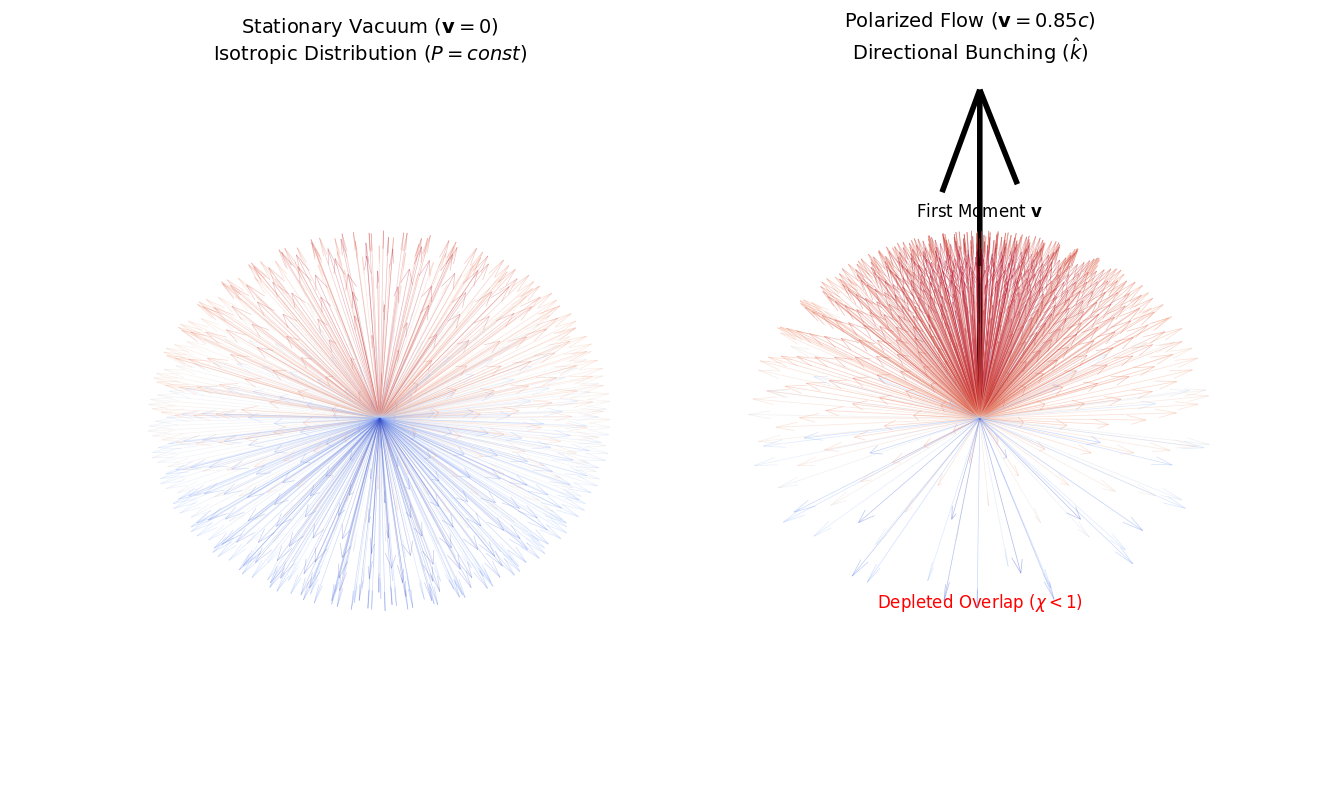

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

def generate_null_sphere(beta=0.0, num_vectors=500):
    # 1. Generate isotropic points (Golden Spiral method)
    indices = np.arange(0, num_vectors, dtype=float) + 0.5
    phi = np.arccos(1 - 2*indices/num_vectors)
    theta = np.pi * (1 + 5**0.5) * indices

    # Convert to Cartesian
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)

    # 2. Apply Relativistic Aberration
    if beta != 0:
        cos_phi = z
        cos_phi_prime = (cos_phi + beta) / (1 + beta * cos_phi)
        phi_prime = np.arccos(cos_phi_prime)

        x = np.sin(phi_prime) * np.cos(theta)
        y = np.sin(phi_prime) * np.sin(theta)
        z = np.cos(phi_prime)

    return x, y, z

def plot_theory_visualization_final():
    fig = plt.figure(figsize=(16, 8))

    # --- CONFIGURATION ---
    beta_val = 0.85
    num_vecs = 600

    # --- PLOT 1: STATIONARY ---
    ax1 = fig.add_subplot(121, projection='3d')
    x0, y0, z0 = generate_null_sphere(beta=0.0, num_vectors=num_vecs)
    colors0 = cm.coolwarm(z0/2 + 0.5)

    ax1.quiver(0, 0, 0, x0, y0, z0, length=1.0, color=colors0, alpha=0.3, arrow_length_ratio=0.1, lw=0.5)

    v_net_0 = np.array([np.mean(x0), np.mean(y0), np.mean(z0)])
    ax1.quiver(0, 0, 0, v_net_0[0], v_net_0[1], v_net_0[2], color='black', lw=3, label=r'$\mathbf{v} = 0$')

    ax1.set_title(r"Stationary Vacuum ($\mathbf{v}=0$)" + "\n" + r"Isotropic Distribution ($P = const$)", fontsize=14)
    ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])
    ax1.axis('off')

    # --- PLOT 2: MOVING ---
    ax2 = fig.add_subplot(122, projection='3d')
    x1, y1, z1 = generate_null_sphere(beta=beta_val, num_vectors=num_vecs)
    colors1 = cm.coolwarm(z1/2 + 0.5)

    ax2.quiver(0, 0, 0, x1, y1, z1, length=1.0, color=colors1, alpha=0.4, arrow_length_ratio=0.1, lw=0.5)

    v_net = np.array([np.mean(x1), np.mean(y1), np.mean(z1)]) * 3
    ax2.quiver(0, 0, 0, v_net[0], v_net[1], v_net[2], color='k', lw=4, label=r'$\mathbf{v}$ (Drift)')

    ax2.text(0, 0, 1.3, r"First Moment $\mathbf{v}$", color='black', fontsize=12, ha='center')
    ax2.text(0, 0, -1.3, r"Depleted Overlap ($\chi < 1$)", color='red', fontsize=12, ha='center')

    ax2.set_title(r"Polarized Flow ($\mathbf{v} = 0.85c$)" + "\n" + r"Directional Bunching ($\hat{k}$)", fontsize=14)
    ax2.set_xlim([-1, 1]); ax2.set_ylim([-1, 1]); ax2.set_zlim([-1, 1])
    ax2.axis('off')

    # --- THE FINAL ADJUSTMENT ---
    # wspace=-0.4 is the perfect balance.
    plt.subplots_adjust(left=0.0, right=1.0, wspace=-0.4, top=0.95, bottom=0.05)

    # Save the figure with tight bounding box to remove extra white space
    # plt.savefig('sphere_model.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_theory_visualization_final()

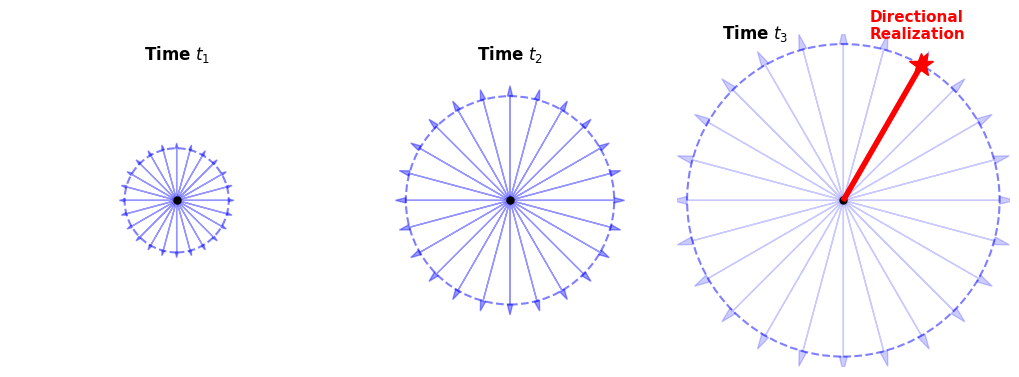

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_expanding_causality_final():
    # FIGSIZE CHANGE: (10, 4) makes the figure narrower, forcing panels closer
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    # Time steps
    times = [1.0, 2.0, 3.0]

    # Common properties
    num_rays = 24
    angles = np.linspace(0, 2*np.pi, num_rays, endpoint=False)

    # The "Selected" direction
    selected_idx = 4
    selected_angle = angles[selected_idx]

    for i, ax in enumerate(axes):
        t = times[i]
        radius = t

        # 1. Draw the "Wavefront"
        circle = plt.Circle((0, 0), radius, color='blue', fill=False, linestyle='--', linewidth=1.5, alpha=0.5)
        ax.add_artist(circle)

        # 2. Draw the "Null Vectors"
        for angle in angles:
            dx = radius * np.cos(angle)
            dy = radius * np.sin(angle)

            alpha_val = 0.2 if i == 2 else 0.4

            ax.arrow(0, 0, dx, dy, head_width=0.05*t, head_length=0.1*t,
                     fc='blue', ec='blue', alpha=alpha_val)

        # 3. Draw the "Source"
        ax.plot(0, 0, 'ko', markersize=5)

        # 4. SPECIAL FOR PANEL 3: The Interaction
        if i == 2:
            dx_sel = radius * np.cos(selected_angle)
            dy_sel = radius * np.sin(selected_angle)

            # The Vector
            ax.arrow(0, 0, dx_sel, dy_sel, head_width=0.2, head_length=0.25,
                     fc='red', ec='red', width=0.08, zorder=10)

            # The Measurement Event
            ax.plot(dx_sel, dy_sel, 'r*', markersize=18, zorder=11)

            # UPDATED TERMINOLOGY: "Path Selection"
            ax.text(dx_sel - 1.0, dy_sel + 0.5, "Directional\nRealization",
                    color='red', fontsize=11, fontweight='bold')

        # Styling
        limit = 3.2 # Tightened limits slightly
        ax.set_xlim(-limit, limit)
        ax.set_ylim(-limit, limit)
        ax.set_aspect('equal')
        ax.axis('off')

# Title inside the plot to save vertical space
        if i == 2:
            # Move t3 left (x = -1.0) and up (y = limit - 0.2)
            ax.text(-1.7, limit - 0.1, f"Time $t_{i+1}$", ha='center', fontsize=12, fontweight='bold')
        else:
            # Keep t1 and t2 centered
            ax.text(0, limit - 0.5, f"Time $t_{i+1}$", ha='center', fontsize=12, fontweight='bold')

    # --- AGGRESSIVE SPACING ---
    # wspace=0 + Narrow Figsize = Touching Circles
    plt.subplots_adjust(left=0.0, right=1.0, wspace=0.0, top=1.0, bottom=0.0)

    plt.show()

plot_expanding_causality_final()

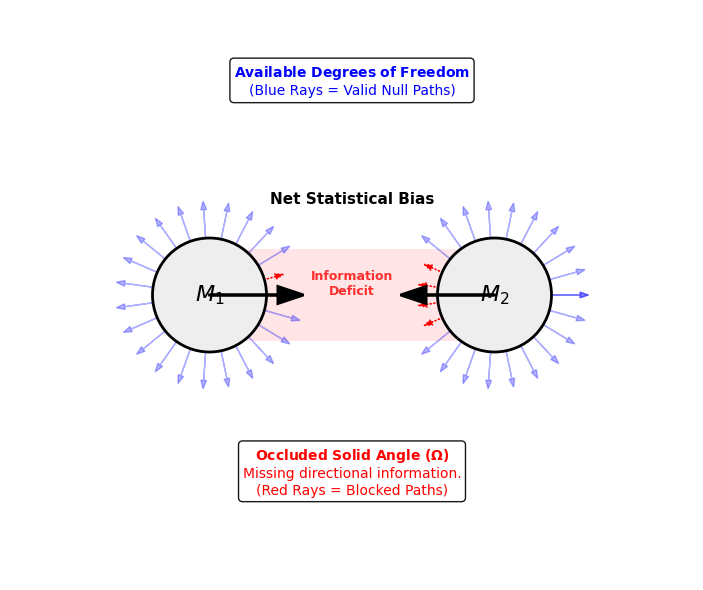

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_entropic_gravity_final_clean():
    fig, ax = plt.subplots(figsize=(10, 6))

    # --- SETUP ---
    m1_center = (-2.5, 0)
    m2_center = (2.5, 0)
    radius = 1.0

    # Draw Mass 1
    m1 = patches.Circle(m1_center, radius, linewidth=2, edgecolor='black', facecolor='#eeeeee', zorder=10)
    ax.add_patch(m1)
    ax.text(m1_center[0], m1_center[1], "$M_1$", ha='center', va='center', fontsize=16, fontweight='bold', zorder=11)

    # Draw Mass 2
    m2 = patches.Circle(m2_center, radius, linewidth=2, edgecolor='black', facecolor='#eeeeee', zorder=10)
    ax.add_patch(m2)
    ax.text(m2_center[0], m2_center[1], "$M_2$", ha='center', va='center', fontsize=16, fontweight='bold', zorder=11)

    # --- THE "CONE OF OCCLUSION" ---
    # Shade the region between them to represent the lost solid angle
    occlusion_zone = patches.Polygon([
        (-2.5, radius*0.8), (2.5, radius*0.8),
        (2.5, -radius*0.8), (-2.5, -radius*0.8)
    ], closed=True, facecolor='red', alpha=0.1, edgecolor=None)
    ax.add_patch(occlusion_zone)

    # Draw "Sight Lines" (Directional Degrees of Freedom)
    # Radiating from M1
    for angle in np.linspace(0, 2*np.pi, 24):
        dx = 1.5 * np.cos(angle)
        dy = 1.5 * np.sin(angle)

        # If the line points towards M2 (Right side), make it Dotted Red (Blocked)
        if -0.5 < angle < 0.5:
             ax.arrow(m1_center[0], m1_center[1], dx*0.8, dy*0.8, head_width=0.1, color='red', linestyle=':')
        # Otherwise, make it Solid Blue (Available)
        else:
             ax.arrow(m1_center[0], m1_center[1], dx, dy, head_width=0.1, color='blue', alpha=0.3)

    # Radiating from M2
    for angle in np.linspace(0, 2*np.pi, 24):
        dx = 1.5 * np.cos(angle)
        dy = 1.5 * np.sin(angle)

        # If the line points towards M1 (Left side), make it Dotted Red (Blocked)
        if 2.6 < angle < 3.7:
             ax.arrow(m2_center[0], m2_center[1], dx*0.8, dy*0.8, head_width=0.1, color='red', linestyle=':')
        else:
             ax.arrow(m2_center[0], m2_center[1], dx, dy, head_width=0.1, color='blue', alpha=0.3)


    # --- THE STATISTICAL RESULT ---
    # Force Arrows
    ax.arrow(m1_center[0], m1_center[1], 1.2, 0, head_width=0.3, fc='black', ec='black', lw=2, zorder=12)
    ax.arrow(m2_center[0], m2_center[1], -1.2, 0, head_width=0.3, fc='black', ec='black', lw=2, zorder=12)

    # Labels for Forces (MOVED)
    # Now centered at x=0, and raised to y=1.6 to sit above the "Information Deficit" label
    ax.text(0, 1.6, "Net Statistical Bias", ha='center', fontsize=11, color='black', fontweight='bold')

    # --- ANNOTATIONS ---
    props = dict(boxstyle='round', facecolor='white', alpha=0.9)

    # Label 1: Available Directions
    ax.text(0, 3.5, r"$\bf{Available\ Degrees\ of\ Freedom}$" + "\n(Blue Rays = Valid Null Paths)",
            color='blue', bbox=props, ha='center')

    # Label 2: The Blockage
    ax.text(0, -3.5, r"$\bf{Occluded\ Solid\ Angle\ (\Omega)}$" + "\nMissing directional information." + "\n(Red Rays = Blocked Paths)",
            color='red', bbox=props, ha='center')

    # Label 3: The Center
    ax.text(0, 0, "Information\nDeficit", color='red', alpha=0.8, ha='center', fontsize=9, fontweight='bold')

    # --- STYLING ---
    ax.set_xlim(-6, 6)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.axis('off')

    # REMOVED TITLE
    # ax.set_title("Gravity as Directional Occlusion (Entropic Bias)", fontsize=16, fontweight='bold', y=1.05)

    plt.tight_layout()
    plt.show()

plot_entropic_gravity_final_clean()

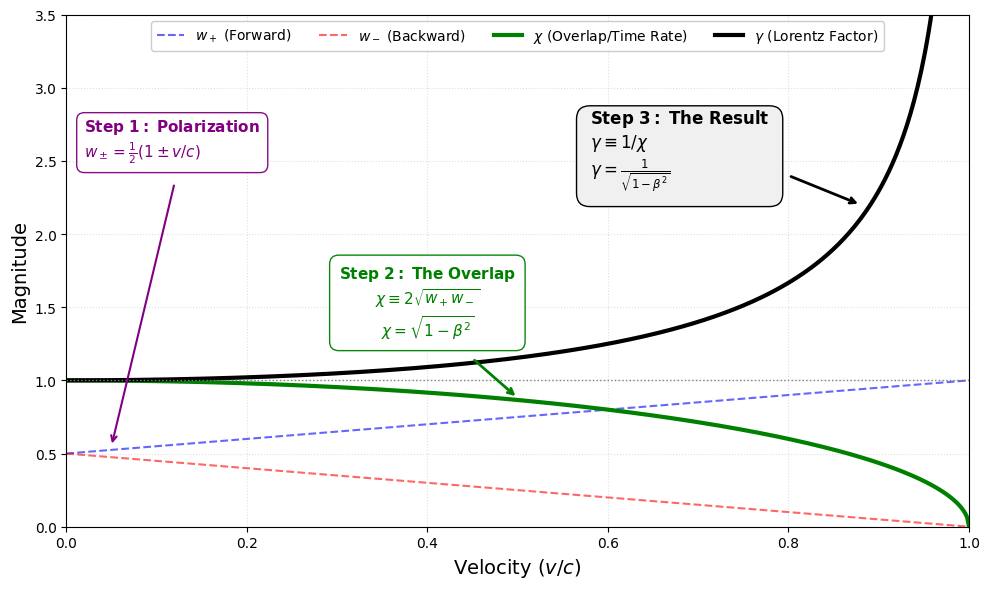

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gamma_final_purple_v2_no_title():
    # --- DATA GENERATION ---
    # 1. Full range for finite values (Weights & Overlap)
    beta_full = np.linspace(0, 1.0, 500)
    # 2. Restricted range for Gamma (avoids divide by zero)
    beta_gamma = np.linspace(0, 0.995, 500)

    # Calculate Data
    w_plus = 0.5 * (1 + beta_full)
    w_minus = 0.5 * (1 - beta_full)
    chi = 2 * np.sqrt(w_plus * w_minus)

    # Calculate Gamma
    chi_gamma = np.sqrt(1 - beta_gamma**2)
    gamma = 1 / chi_gamma

    # --- PLOTTING SETUP ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set Limits
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 3.5)

    # --- PLOT THE CURVES ---
    ax.plot(beta_full, w_plus, color='blue', linestyle='--', linewidth=1.5, alpha=0.6, label=r'$w_+$ (Forward)')
    ax.plot(beta_full, w_minus, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label=r'$w_-$ (Backward)')
    ax.plot(beta_full, chi, color='green', linewidth=3, label=r'$\chi$ (Overlap/Time Rate)')
    ax.plot(beta_gamma, gamma, color='black', linewidth=3, label=r'$\gamma$ (Lorentz Factor)')

    # --- ANNOTATIONS ---

    # Box Properties
    box_props_purple = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='purple', alpha=0.95, zorder=10)
    box_props_green = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='green', alpha=0.95, zorder=10)
    box_props_black = dict(boxstyle='round,pad=0.8', facecolor='#f0f0f0', edgecolor='black', zorder=10)

    # --- BOX 1: Step 1 (Purple) ---
    # Position: Top Left
    ax.text(0.02, 2.8,
            r"$\bf{Step\ 1:\ Polarization}$" + "\n" +
            r"$w_\pm = \frac{1}{2}(1 \pm v/c)$",
            fontsize=11, color='purple', bbox=box_props_purple, verticalalignment='top')

    # Arrow 1: Purple
    ax.annotate("", xy=(0.05, 0.55), xytext=(0.12, 2.35),
                arrowprops=dict(arrowstyle="->", color='purple', lw=1.5))

    # --- BOX 2: Step 2 (Green) ---
    # Position: Center
    ax.text(0.40, 1.3,
            r"$\bf{Step\ 2:\ The\ Overlap}$" + "\n" +
            r"$\chi \equiv 2\sqrt{w_+ w_-}$" + "\n" +
            r"$\chi = \sqrt{1 - \beta^2}$",
            fontsize=11, color='green', bbox=box_props_green, horizontalalignment='center')

    # Arrow 2: Green
    ax.annotate("", xy=(0.5, 0.88), xytext=(0.45, 1.15),
                arrowprops=dict(arrowstyle="->", color='green', lw=2))

    # --- BOX 3: Step 3 (Black) ---
    # Position: Left (x=0.58)
    ax.text(0.58, 2.4,
            r"$\bf{Step\ 3:\ The\ Result}$" + "\n" +
            r"$\gamma \equiv 1 / \chi$" + "\n" +
            r"$\gamma = \frac{1}{\sqrt{1-\beta^2}}$",
            fontsize=12, fontweight='bold', color='black', bbox=box_props_black)

    # Arrow 3: Black
    ax.annotate("", xy=(0.88, 2.2), xytext=(0.80, 2.4),
                arrowprops=dict(arrowstyle="->", color='black', lw=2))

    # --- STYLING ---
    ax.set_xlabel(r"Velocity ($v/c$)", fontsize=14)
    ax.set_ylabel("Magnitude", fontsize=14)

    # REMOVED TITLE
    # ax.set_title("Deriving Relativity from Statistical Overlap", fontsize=16, fontweight='bold', pad=20)

    ax.grid(True, linestyle=':', alpha=0.4)

    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=4, framealpha=1.0)

    # 1.0 Line
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)

    plt.tight_layout()
    plt.show()

plot_gamma_final_purple_v2_no_title()

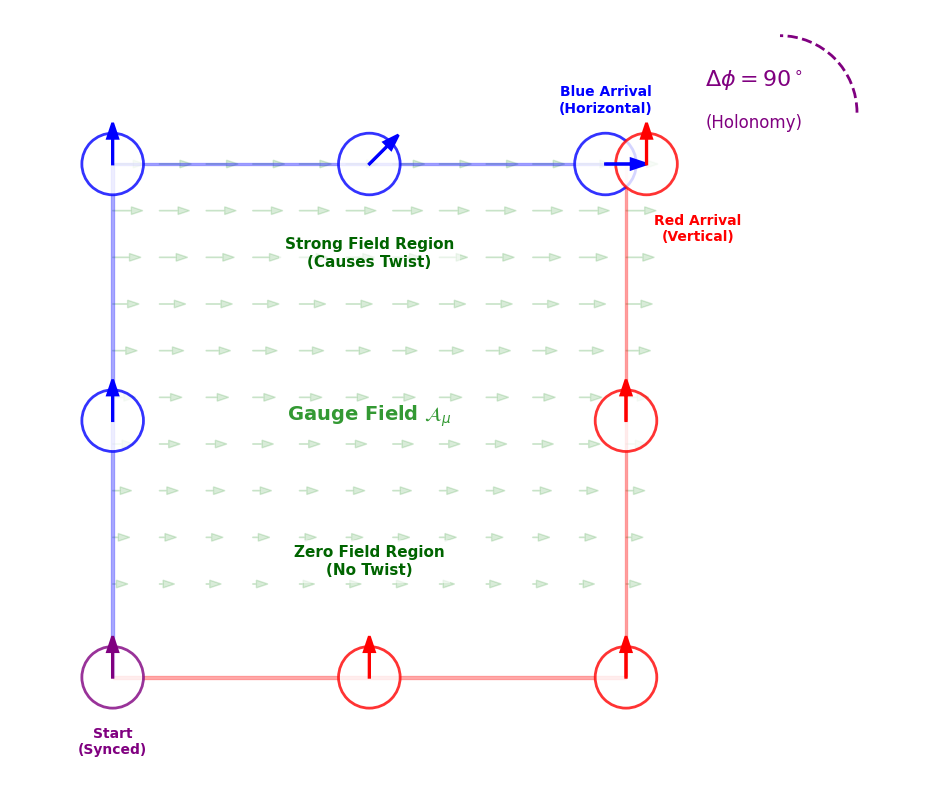

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_gauge_holonomy_final_overlap():
    fig, ax = plt.subplots(figsize=(10, 8)) # Adjusted aspect for better fit

    # --- 1. DRAW THE BACKGROUND FIELD ---
    for x in np.linspace(0, 1, 12):
        for y in np.linspace(0, 1, 12):
            field_strength = y
            if field_strength > 0.1:
                ax.arrow(x, y, 0.04 * field_strength, 0,
                         color='green', alpha=0.15, head_width=0.015)

    # TEXT LABELS
    ax.text(0.5, 0.8, "Strong Field Region\n(Causes Twist)",
            color='darkgreen', alpha=1.0, ha='center', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

    ax.text(0.5, 0.2, "Zero Field Region\n(No Twist)",
            color='darkgreen', alpha=1.0, ha='center', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

    ax.text(0.5, 0.5, r"Gauge Field $\mathcal{A}_\mu$",
            color='green', alpha=0.8, ha='center', fontsize=14, fontweight='bold')

    # --- 2. CLOCK DRAWING FUNCTION ---
    def draw_clock(x, y, angle_rad, color, label=None, label_pos='top', label_offset_x=0):
        # Clock Face (Alpha added to fill to see overlap)
        circle = patches.Circle((x, y), 0.06, facecolor='white', edgecolor=color, linewidth=2, zorder=10, alpha=0.8)
        ax.add_patch(circle)

        # Clock Hand
        dx = 0.05 * np.cos(angle_rad)
        dy = 0.05 * np.sin(angle_rad)
        ax.arrow(x, y, dx, dy, head_width=0.02, color=color, zorder=11, lw=2)

        if label:
            y_offset = 0.1 if label_pos == 'top' else -0.15
            ax.text(x + label_offset_x, y + y_offset, label, color=color, ha='center', fontsize=10, fontweight='bold')

    # --- 3. THE PATHS ---

    # START (Purple)
    draw_clock(0, 0, np.pi/2, 'purple', "Start\n(Synced)", label_pos='bottom')

    # === RED PATH (Bottom) ===
    # Path Lines
    ax.arrow(0, 0, 1, 0, color='red', alpha=0.3, width=0.005, head_width=0)
    ax.arrow(1, 0, 0, 1, color='red', alpha=0.3, width=0.005, head_width=0)

    draw_clock(0.5, 0, np.pi/2, 'red')
    draw_clock(1.0, 0, np.pi/2, 'red')
    draw_clock(1.0, 0.5, np.pi/2, 'red')

    # === BLUE PATH (Top) ===
    # Path Lines
    ax.arrow(0, 0, 0, 1, color='blue', alpha=0.3, width=0.005, head_width=0)
    ax.arrow(0, 1, 1, 0, color='blue', alpha=0.3, width=0.005, head_width=0)

    draw_clock(0, 0.5, np.pi/2, 'blue')
    draw_clock(0, 1.0, np.pi/2, 'blue')
    draw_clock(0.5, 1.0, np.pi/4, 'blue')

    # --- 4. THE OVERLAPPING ARRIVAL ---
    # Concept: They are at (1,1).
    # Visual: We shift them just slightly apart so they overlap but you see both arrows.

    # Blue Arrival (Slightly Left of 1.0)
    draw_clock(0.96, 1.0, 0, 'blue', "Blue Arrival\n(Horizontal)", label_pos='top')

    # Red Arrival (Slightly Right of 1.0)
    # Added label_offset_x=0.1 to push the text further right
    draw_clock(1.04, 1.0, np.pi/2, 'red', "Red Arrival\n(Vertical)", label_pos='bottom', label_offset_x=0.1)

    # --- 5. THE RESULT ---
    target_x = 1.25
    target_y = 1.15

    ax.text(target_x, target_y, r"$\Delta \phi = 90^\circ$", color='purple', fontsize=16, ha='center', fontweight='bold')
    ax.text(target_x, target_y - 0.08, "(Holonomy)", color='purple', fontsize=12, ha='center')

    # Visual Arc
    arc = patches.Arc((1.30, 1.1), 0.3, 0.3, theta1=0, theta2=90, color='purple', lw=2, ls='--')
    ax.add_patch(arc)

    # --- STYLING ---
    ax.set_aspect('equal')
    ax.set_xlim(-0.2, 1.6)
    ax.set_ylim(-0.2, 1.3)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('holonomy.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_gauge_holonomy_final_overlap()

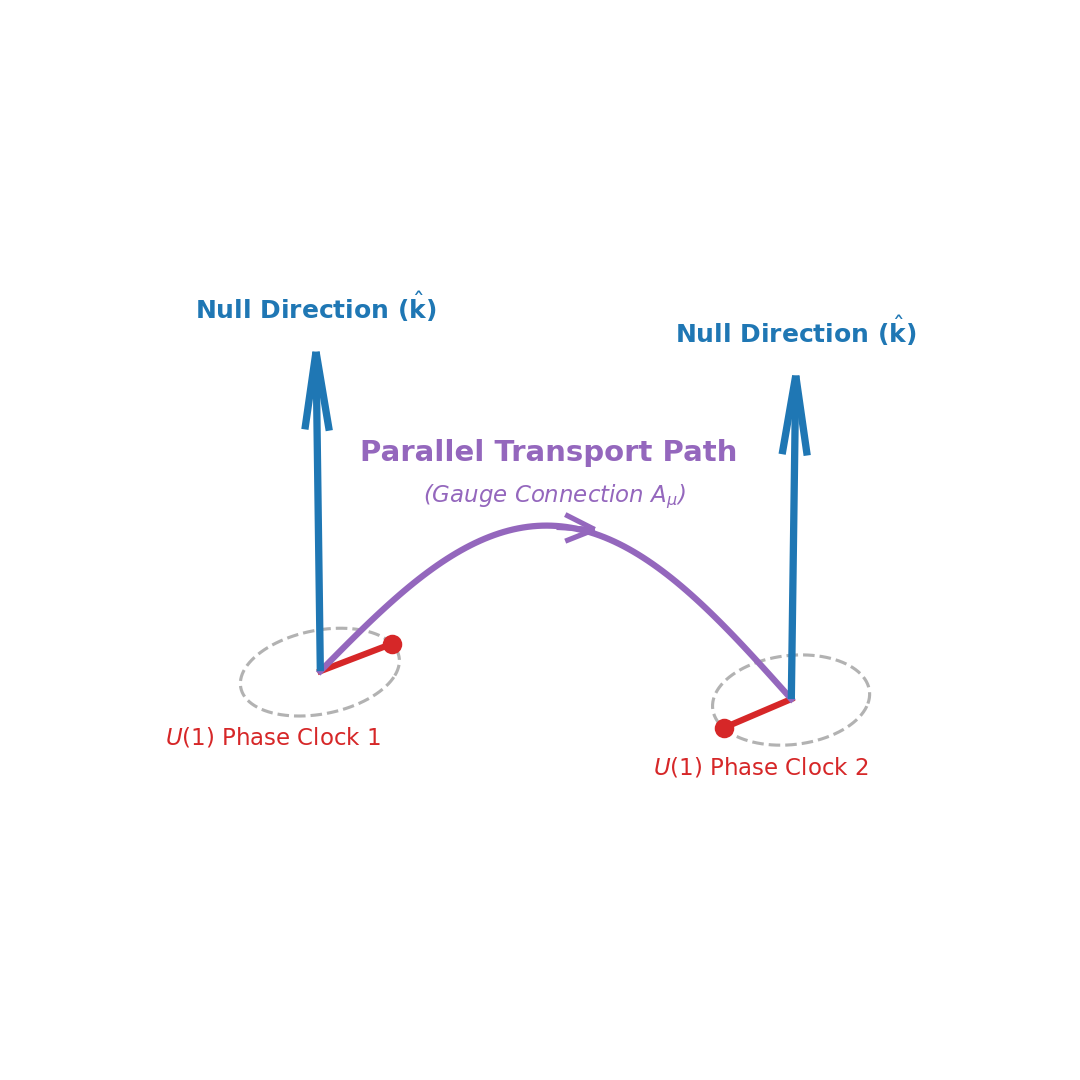

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the figure with a slightly wider canvas
fig = plt.figure(figsize=(12, 7), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# 1. Spread the spatial points much further apart to prevent overlap
p1 = np.array([-2.5, 0, 0])
p2 = np.array([2.5, 0, 0])

# Make the directional arrows (k-hat) taller
vec_dir = np.array([0, 0, 2.0])

# Draw the Directional Arrows (The observable state)
ax.quiver(p1[0], p1[1], p1[2], vec_dir[0], vec_dir[1], vec_dir[2],
          color='#1f77b4', linewidth=3.5, arrow_length_ratio=0.25, clip_on=False)
ax.quiver(p2[0], p2[1], p2[2], vec_dir[0], vec_dir[1], vec_dir[2],
          color='#1f77b4', linewidth=3.5, arrow_length_ratio=0.25, clip_on=False)

# Function to draw the U(1) phase "clock face"
def draw_phase_clock(ax, center, radius, phase_angle, label):
    # Draw the dashed circular fiber
    theta = np.linspace(0, 2*np.pi, 100)
    x = center[0] + radius * np.cos(theta)
    y = center[1] + radius * np.sin(theta)
    z = np.full_like(x, center[2])
    ax.plot(x, y, z, color='gray', linestyle='--', alpha=0.6)

    # Draw the specific phase "clock hand"
    hx = center[0] + radius * np.cos(phase_angle)
    hy = center[1] + radius * np.sin(phase_angle)
    hz = center[2]
    ax.plot([center[0], hx], [center[1], hy], [center[2], hz], color='#d62728', linewidth=3)
    ax.scatter([hx], [hy], [hz], color='#d62728', s=70) # Dot at the end of the hand

    # Label the phase
    ax.text(center[0], center[1] - radius - 0.5, center[2], label, color='#d62728', fontsize=11, ha='center')

# 2. Draw the Phase Clocks
radius = 0.8
phase1 = np.pi / 4       # Pointing to "1:30"
phase2 = 5 * np.pi / 4   # Pointing to "7:30" (Completely out of the way)
draw_phase_clock(ax, p1, radius, phase1, r'$U(1)$ Phase Clock 1')
draw_phase_clock(ax, p2, radius, phase2, r'$U(1)$ Phase Clock 2')

# 3. Draw the Connection Field A_mu (The Purple Sync Rule)
t = np.linspace(0, 1, 100)
x_curve = p1[0] + (p2[0] - p1[0]) * t
y_curve = np.zeros_like(t)
# Make the arch high so it clears the clocks entirely
z_curve = 1.0 * np.sin(np.pi * t)
ax.plot(x_curve, y_curve, z_curve, color='#9467bd', linestyle='-', linewidth=3)

# Add a perfectly sized directional arrowhead to the peak of the arch
mid = 50
z_offset = 0.009  # Tweak this number to move the arrow up or down
ax.quiver(x_curve[mid], y_curve[mid], z_curve[mid] - z_offset,
          1, 0, 0,
          color='#9467bd', length=0.4, normalize=True, arrow_length_ratio=0.8, linewidth=2.5)
# 4. Add Text Labels
ax.text(p1[0], p1[1], p1[2] + 2.2, r'Null Direction ($\hat{\mathbf{k}}$)', color='#1f77b4', fontsize=12, ha='center', weight='bold')
ax.text(p2[0], p2[1], p2[2] + 2.2, r'Null Direction ($\hat{\mathbf{k}}$)', color='#1f77b4', fontsize=12, ha='center', weight='bold')

# Put the Purple text ABOVE the arch
ax.text(0, 0, 1.4, r'Parallel Transport Path ', color='#9467bd', fontsize=14, ha='center', weight='bold')
ax.text(0, 0, 1.15, r'(Gauge Connection $A_\mu$)', color='#9467bd', fontsize=11, ha='center', style='italic')

# Clean up the view (expand the box uniformly)
ax.set_xlim([-4.0, 4.0])
ax.set_ylim([-3.0, 3.0])
ax.set_zlim([-1.0, 4.0])
ax.axis('off')

# Clean up the view (hide axes and expand the invisible bounding box)
ax.set_xlim([-3.5, 3.5])
ax.set_ylim([-2.0, 2.0])
ax.set_zlim([-0.5, 2.5])
ax.axis('off')

# Set camera angle
ax.view_init(elev=18, azim=-80)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

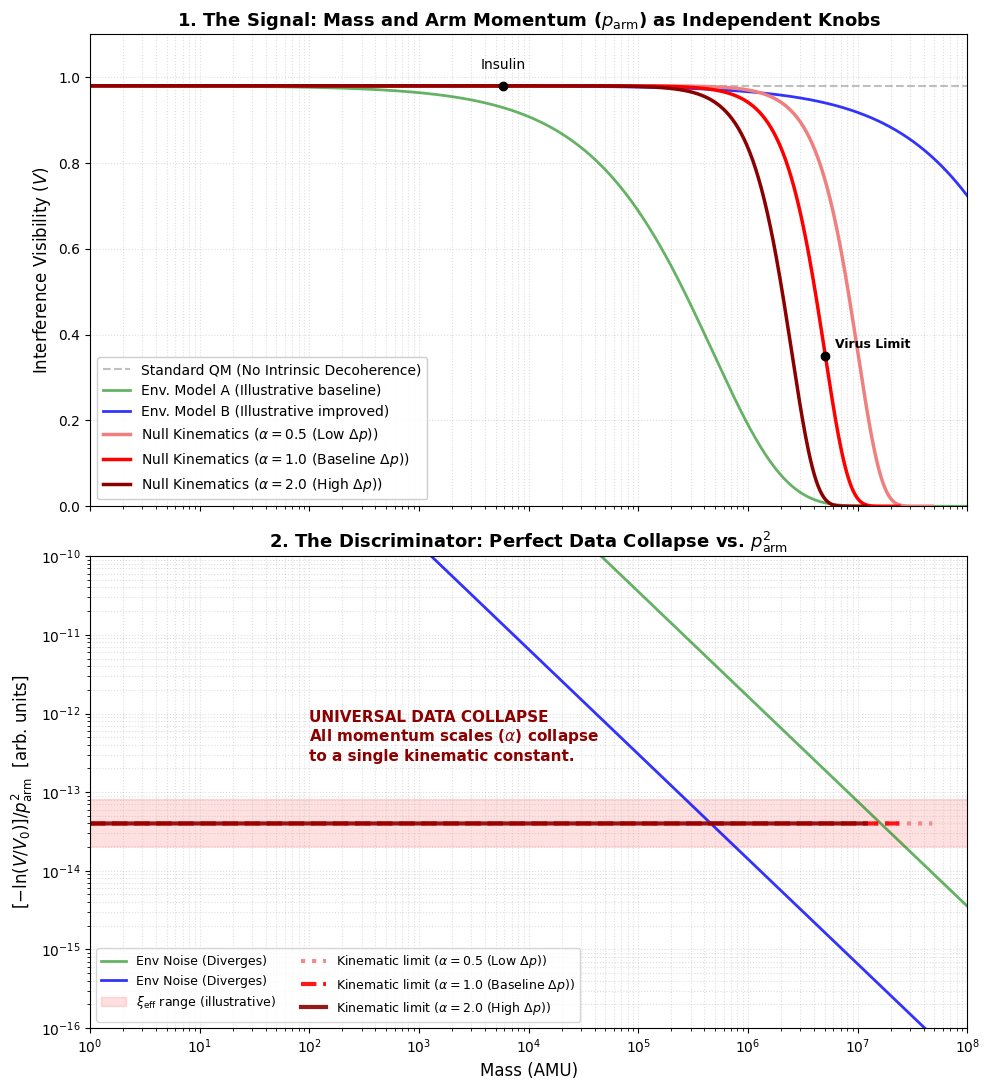

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_discriminator_data_collapse():
    # Mass axis (Keeping this so we don't lose our Insulin/Virus physical anchors)
    m_amu = np.logspace(0, 8, 900)
    V0 = 0.98

    # --- 1. Standard QM (Baseline) ---
    V_gravity_only = V0 * np.ones_like(m_amu)

    # --- 2. Environmental Models (Illustrative placeholders) ---
    p_col = 2/3
    p_bb  = 2/3
    n_bb  = 3
    m_c   = 3e6
    m_b   = 8e5
    P0    = 1.0
    T0    = 300.0

    def V_env(m, P, T):
        D_col = (P / P0) * (m / m_c)**p_col
        D_bb  = (T / T0)**n_bb * (m / m_b)**p_bb
        D_tot = D_col + D_bb
        return V0 * np.exp(-D_tot)

    # Scenarios (labeled as illustrative)
    V_env_base = V_env(m_amu, 1.0, 300.0)
    V_env_impr = V_env(m_amu, 1e-2, 60.0)

    # --- Diagnostics Calculation Function ---
    def neglog_ratio(V):
        eps = 1e-16
        val = np.clip(V / V0, eps, 1.0)
        return -np.log(val)

    # --- 3. Null Kinematics (The p^2 Prediction using Momentum Scale Alpha) ---
    m_star = 5e6 # Baseline transition mass

    # Define uncertainty bounds for the illustrative band
    m_star_lower = 3.5e6
    m_star_upper = 7.0e6

    # Define relative arm momentum scales: p_arm = alpha * p_0
    alphas = [0.5, 1.0, 2.0]
    colors = ["lightcoral", "red", "darkred"]
    line_styles = [":", "--", "-"] # Different styles to show overlap in Panel 2
    labels = [r"$\alpha = 0.5$ (Low $\Delta p$)",
              r"$\alpha = 1.0$ (Baseline $\Delta p$)",
              r"$\alpha = 2.0$ (High $\Delta p$)"]

    # --- PLOTTING (2 PANELS) ---
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(10, 11), sharex=True)

    # === PANEL 1: VISIBILITY ===
    ax1.set_xscale("log")
    ax1.set_ylim(0, 1.1)
    ax1.set_xlim(1, 1e8)

    ax1.plot(m_amu, V_gravity_only, "--", color="gray", lw=1.5, alpha=0.5,
             label="Standard QM (No Intrinsic Decoherence)")

    ax1.plot(m_amu, V_env_base, color="green", lw=2, alpha=0.6,
             label="Env. Model A (Illustrative baseline)")
    ax1.plot(m_amu, V_env_impr, color="blue", lw=2, alpha=0.8,
             label="Env. Model B (Illustrative improved)")

    # Plot the three momentum scale curves for Null Kinematics
    for a, col, lab in zip(alphas, colors, labels):
        # p^2 scaling means the exponent scales with (m * a)^2
        V_null = V0 * np.exp(-(m_amu / m_star)**2 * a**2)

        mask = V_null > 1e-10
        ax1.plot(m_amu[mask], V_null[mask], color=col, lw=2.5, label=f"Null Kinematics ({lab})")

    # --- Markers + Labels ---
    ax1.plot(5800, V0, "ko", zorder=10)
    ax1.text(5800, 1.02, "Insulin", ha="center", fontsize=10)

    virus_x, virus_y = 5e6, 0.35
    ax1.plot(virus_x, virus_y, "ko", zorder=10)
    ax1.text(30.0e6, 0.37, "Virus Limit", ha="right", color="black", fontweight="bold", fontsize=9)

    ax1.set_ylabel("Interference Visibility ($V$)", fontsize=12)
    ax1.set_title(r"1. The Signal: Mass and Arm Momentum ($p_{\rm arm}$) as Independent Knobs", fontweight="bold", fontsize=13)
    ax1.grid(True, which="both", linestyle=":", alpha=0.4)
    ax1.legend(loc="lower left", fontsize=10, framealpha=0.95)

    # === PANEL 2: THE DATA COLLAPSE ===
    ax3.set_xscale("log")
    ax3.set_yscale("log")
    ax3.set_ylim(1e-16, 1e-10)
    ax3.set_xlim(1, 1e8)

    # For the environmental background, we plot them normalized by baseline momentum (alpha=1)
    Y_env_base = neglog_ratio(V_env_base)
    Y_env_impr = neglog_ratio(V_env_impr)
    R_env_base = Y_env_base / (m_amu**2 * 1.0**2)
    R_env_impr = Y_env_impr / (m_amu**2 * 1.0**2)

    ax3.plot(m_amu, R_env_base, color="green", lw=2, alpha=0.6, label="Env Noise (Diverges)")
    ax3.plot(m_amu, R_env_impr, color="blue", lw=2, alpha=0.8, label="Env Noise (Diverges)")

    # Plot the Uncertainty Band first so it sits behind the lines
    R_lower = 1.0 / (m_star_upper**2)
    R_upper = 1.0 / (m_star_lower**2)
    ax3.fill_between(m_amu, R_lower, R_upper, color="red", alpha=0.12,
                     label=r"$\xi_{\rm eff}$ range (illustrative)")

    # Plot the three kinematics curves normalized by p_arm^2 (alpha^2 * m^2)
    # THIS CREATES THE DATA COLLAPSE
    for a, col, ls, lab in zip(alphas, colors, line_styles, labels):
        V_null = V0 * np.exp(-(m_amu / m_star)**2 * a**2)
        Y_null = neglog_ratio(V_null)

        # Normalize strictly by the momentum squared scale
        R_null_collapse = Y_null / ((a * m_amu)**2)

        mask = V_null > 1e-10
        # Syncing colors with Panel 1, keeping different linestyles for visibility
        ax3.plot(m_amu[mask], R_null_collapse[mask], color=col, lw=3, linestyle=ls, alpha=0.9,
                 label=f"Kinematic limit ({lab})")

    text_str = (
        "UNIVERSAL DATA COLLAPSE\n" +
        r"All momentum scales ($\alpha$) collapse" + "\n" +
        "to a single kinematic constant."
    )

    # Shifted text slightly so it doesn't overlap the new uncertainty band
    ax3.text(1e2, 2.5e-13, text_str, color="darkred", fontweight="bold", fontsize=11)

    ax3.set_xlabel("Mass (AMU)", fontsize=12)
    ax3.set_ylabel(r"$[-\ln(V/V_0)] / p_{\rm arm}^2$  [arb. units]", fontsize=12)
    ax3.set_title(r"2. The Discriminator: Perfect Data Collapse vs. $p_{\rm arm}^2$", fontweight="bold", fontsize=13)
    ax3.grid(True, which="both", linestyle=":", alpha=0.4)

    ax3.legend(loc="lower left", fontsize=9, ncol=2)

    plt.tight_layout()
    plt.savefig("Discriminator_Momentum_Collapse_Band.png", dpi=300, bbox_inches="tight")
    plt.show()

# Run it
plot_discriminator_data_collapse()